##### 01_pairwise_bootstrap.ipynb

### Author: Lewis Kunik - University of Utah
### Contact: lewiskunik@gmail.com

##### <u>Description:</u>
This notebook demonstrates how to perform the pairwise bootstrap method described in the paper:
Kunik et al. (2026) 'Characterizing the effects of tree mortality from wildfire and bark beetles using satellite observations of solar-induced chlorophyll fluorescence'

In this notebook, I will outline the methods used to resample pixels from the mortality group (here we will use low-severity wildfire as the example) and to select pixels from the control group that are biogeographically similar to those of the mortality group. 


First load necessary packages and functions:

In [1]:

#########################################
# Load packages
#########################################

#%%
# File system packages
import os  # operating system library
import sys
import time

# Load the custom modules included in the 'include' directory
sys.path.append('include')
import bootstrap_functions as functions
import bootstrap_map_functions as map_functions

# runtime packages
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Suppress UserWarning about centroid in geographic CRS globally
warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect.*")

# numerical/data management packages
import numpy as np
import xarray as xr  # for multi dimensional data
import pandas as pd

# statistical packages
from scipy import stats
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy.stats import gaussian_kde

# shapefile/geospatial packages
import geopandas as gpd
from shapely.geometry import mapping

# plotting packages
from matplotlib import pyplot as plt  # primary plotting module
from IPython import display
import cartopy.crs as ccrs  # for cartopy coordinate reference systems

# image handling packages
import imageio.v2 as imageio
from PIL import Image

# ipython display packages
from IPython.display import clear_output
from IPython.display import Image as IPImage, display

#NOTE that other necessary packages are loaded in the bootstrap_functions.py and bootstrap_map_functions.py files


Now define global filepaths and variables:

In [2]:
#########################################
# Define Global Filepaths
#########################################

# directories
dat_dir = 'data/'
# dat_dir = '/uufs/chpc.utah.edu/common/home/lin-group19/ltk/bootstrap/code/for_github/data'
plot_dir = 'out_plots/'

# path to processed TROPOMI SIF file
SIF_16day_file = os.path.join(dat_dir, 'TROPOMI_SIF740nm_05deg_16d_sample.nc')
SIF_annual_file = os.path.join(dat_dir, 'TROPOMI_SIF_annual_WUS_AUG-OCT.nc')

# path to processed NASA elev DEM file
elev_file = os.path.join(dat_dir, 'SRTM_DEM_05d_WUS.nc')

# path to processed NLCD Tree Canopy Cover file, snapshot of year 2021
TCC_file = os.path.join(dat_dir, 'NLCD_TCC_05d_WUS_2021.nc')

########################################
# Define Global Variables and constants
#########################################

### Variables specific to the dataset 
dat_var = 'sifdc' # this is the name of the variable to be accessed in the dataset
var_units = 'mW/m2/sr/nm'

# Number of bootstrapping iterations to loop through
num_repeats = 100 # normally you would want to use a larger number (e.g. 5000). We use 100 to make the example run faster
plot_pixel_maps = True

include_months_lab = 'Aug-Oct'
include_months_descr = 'late_summer'
discard_months = [11, 12, 1, 2, 3, 4, 5, 6, 7] # define months to discard (months when snowcover may affect signal or when understory may impose strong bias)

control_sample_size = 100 # Number of control pixels to sample for each bootstrap iteration


### Filepaths to mortality/control shapefiles:
control_polygon_filepath = os.path.join(dat_dir,'shp/control_pixels_05d.shp')
mortality_polygon_filepath = os.path.join(dat_dir, 'shp/wildfire_low_pixels_2021_05d.shp') # Can be adjusted for different mortality cases
studyarea_polygon_filepath = os.path.join(dat_dir, 'shp/EPA_L3_ecoregion_studyarea.shp')

# Define pre-disturbance baseline year (2019 was a high-precip year)
baseline_year = 2019

# Define mortality year (adjust based on the mortality polygon used)
mortality_year = 2021


# Define parameters for Kernel Density Estimation of land surface characteristic distributions
elevation_range = np.linspace(0, 4000, 1000)
TCC_range = np.linspace(0, 100, 1000)
latitude_range = np.linspace(36, 48, 1000)

# select for only these years when working with data files
analysis_years = np.array(range(2015, 2024))

# Colors for plotting
mortality_color = "#aa021e" # Line/point color for plots
control_color = "#0219aa"



For simplicity, functions are stored in the bootstrap_functions.py and bootstrap_map_functions.py files in the include directory

In [ ]:
#########################################
# Define Global Functions
#########################################


# See "include/bootstrap_functions.py" and "include/bootstrap_map_functions.py" for the functions used in this script


Start by loading the mortality and control pixels, which are stored as ESRI shapefiles and represented as multipolygon geometries. 

Each polygon defining a pixel includes the longitude and latitude bounds of that grid cell within the raster datasets, plus a very small (0.00005°) buffer on the outside to ensure that the rioxarray clip function will always include the correct data when clipped

This code chunk plots a map of all eligible mortality and control pixels within the bark beetle bootstrap domain

Number of mortality pixels: 161
Number of control pixels: 1315


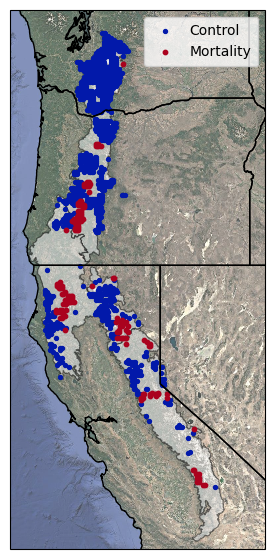

In [3]:
#########################################
# Begin Main
#########################################

### Load geopandas shapefile data for mortality and control pixel superset

# all mortality pixels 
mortality_polygon_gdf = gpd.read_file(mortality_polygon_filepath)
mortality_polygon_geom = mortality_polygon_gdf.geometry.apply(mapping)
num_mortality_pixels = len(mortality_polygon_gdf)

# all control pixels
control_polygon_gdf = gpd.read_file(control_polygon_filepath)
control_polygon_geom = control_polygon_gdf.geometry.apply(mapping)
num_control_pixels = len(control_polygon_gdf)
print(f'Number of mortality pixels: {num_mortality_pixels}')
print(f'Number of control pixels: {num_control_pixels}')

# Plot map of the control and mortality pixels
control_centroids = control_polygon_gdf.centroid
mortality_centroids = mortality_polygon_gdf.centroid
map_functions.plot_mortality_control_pixel_map(control_centroids.x, control_centroids.y, mortality_centroids.x, mortality_centroids.y)


In [4]:

#########################################
# Load DEM, Tree Canopy Cover and satellite RS datasets
#########################################

# Load NASA elev elevation (pre-gridded to 0.05°)
print('Loading elevation dataset')
elev_xr = xr.open_dataset(elev_file).squeeze('band').rename({'lon':'x', 'lat':'y'}).sortby(['x', 'y'])
elev_xr.rio.write_crs(4326, inplace = True) # specify WGS84 as CRS

# Load NLCD Tree Canopy Cover (pre-gridded to 0.05°)
TCC_xr = xr.open_dataset(TCC_file).squeeze('band').rename({'lon':'x', 'lat':'y'}).sortby(['x', 'y']) # Assume grid matches with elevation dataset (already checked)
TCC_xr.rio.write_crs(4326, inplace = True) # specify WGS84 as CRS

# Load TROPOMI SIF 0.05° gridded dataset (pre-processed to represent mean August-October data by year)
SIF_annual_xr = xr.open_dataset(SIF_annual_file, decode_coords='all').sortby(['x', 'y'])
SIF_annual_xr.rio.write_crs(4326, inplace=True)

SIF_16day_xr = xr.open_dataset(SIF_16day_file, decode_coords='all').sortby(['lon', 'lat'])
SIF_16day_xr.rio.write_crs(4326, inplace=True)

latitude_data = np.tile(elev_xr.y.values[:, np.newaxis], (1, elev_xr.x.size))
latitude_da = xr.DataArray(
    latitude_data,
    coords={'y': elev_xr.y.values, 'x': elev_xr.x.values},
    dims=['y', 'x'],
    name='latitude'
)
latitude_da.rio.write_crs(4326, inplace=True)
latitude_ds = latitude_da.to_dataset(name='latitude')


Loading elevation dataset


### Normalizing data to the baseline year and standardizing

An important step in this analysis is representing the data relative to a pre-disturbance baseline on a per-pixel basis. Normally we would prefer to express as a true standardized anomaly using a historical average baseline, but since we only have 6 years of TROPOMI data to work with, the pre-disturbance/pre-drought year works pretty well.

In [5]:
# scale data so that the minimum annual value across all pixels analyzed is 0 and max value is 1 
# (avoids mismatched magnitudes when comparing percent change relative to a baseline year)
SIF_all_mortality = SIF_annual_xr.rio.clip(mortality_polygon_geom, crs=4326) # filter for mortality domain
SIF_all_control = SIF_annual_xr.rio.clip(control_polygon_geom, crs=4326) # filter for control domain
SIF_annual_min = np.min([np.nanmin(SIF_all_mortality[dat_var].values), np.nanmin(SIF_all_control[dat_var].values)])
SIF_annual_max = np.max([np.nanmax(SIF_all_mortality[dat_var].values), np.nanmax(SIF_all_control[dat_var].values)])
SIF_annual_xr_scale = (SIF_annual_xr[dat_var] - SIF_annual_min) / (SIF_annual_max - SIF_annual_min)

Now we compute the Kernel Density Estimation (KDE) of elevation and tree canopy cover (TCC) from the SRTM elevation and NLCD datasets, respectively. We'll also do this for latitude. The KDE represents the smoothed distribution from the histogram of the elevation and TCC data. Density functions (which are the distributions normalized to 1) are also computed.

In [6]:
##################################################################################
# calculate the distributions of elevation and tree canopy cover across the mortality pixels
##################################################################################
   
elev_mortality_kde, elev_mortality_density, elev_mortality_non_nan = functions.compute_kde_density_from_gdf(mortality_polygon_gdf, elev_xr, 'elevation', elevation_range)
elev_control_kde, elev_control_density, elev_control_non_nan = functions.compute_kde_density_from_gdf(control_polygon_gdf, elev_xr, 'elevation', elevation_range)
TCC_mortality_kde, TCC_mortality_density, TCC_mortality_non_nan = functions.compute_kde_density_from_gdf(mortality_polygon_gdf, TCC_xr, 'tree_canopy_cover', TCC_range)
TCC_control_kde, TCC_control_density, TCC_control_non_nan = functions.compute_kde_density_from_gdf(control_polygon_gdf, TCC_xr, 'tree_canopy_cover', TCC_range)
latitude_mortality_kde, latitude_mortality_density, latitude_mortality_non_nan = functions.compute_kde_density_from_gdf(mortality_polygon_gdf, latitude_ds, 'latitude', latitude_range)
latitude_control_kde, latitude_control_density, latitude_control_non_nan = functions.compute_kde_density_from_gdf(control_polygon_gdf, latitude_ds, 'latitude', latitude_range)

elev_mortality_std = np.std(elev_mortality_non_nan)
TCC_mortality_std = np.std(TCC_mortality_non_nan)
latitude_mortality_std = np.std(latitude_mortality_non_nan)

# get std for later - we will convert to z-scores
elev_control_std = np.std(elev_control_non_nan)
TCC_control_std = np.std(TCC_control_non_nan)
latitude_control_std = np.std(latitude_control_non_nan)

# clip the elevation and TCC datasets to the control polygons
elev_xr_control_clip = elev_xr.rio.clip(control_polygon_geom, crs=4326)
TCC_xr_control_clip = TCC_xr.rio.clip(control_polygon_geom, crs=4326)
latitude_xr_control_clip = latitude_ds.rio.clip(control_polygon_geom, crs=4326)

# Flatten the control datasets for use in the bootstrap step
elev_control_flat = elev_xr_control_clip.elevation.data.flatten()
TCC_control_flat = TCC_xr_control_clip.tree_canopy_cover.data.flatten()
latitude_control_flat = latitude_xr_control_clip.latitude.data.flatten()


Let's plot the histograms and the KDEs of the elevation data for the mortality pixel set, as well as for the control pixel set.

### Kolmogorov-smirnov distribution test statistics
We also compute the Kolmogorov-smirnov (K-S) distribution test statistics to compare mortality and control distributions.
For this test, a lower value indicates greater likelihood of similarity between the underlying distributions of two sets of values.
So, LOWER K-S statistic = MORE SIMILARITY between mortality and control groups
And, HIGHER K-S statistic = LESS SIMILARITY between mortality and control groups

Kolmogorov-Smirnov statistic comparing mortality and control distributions of elevation: 0.2901


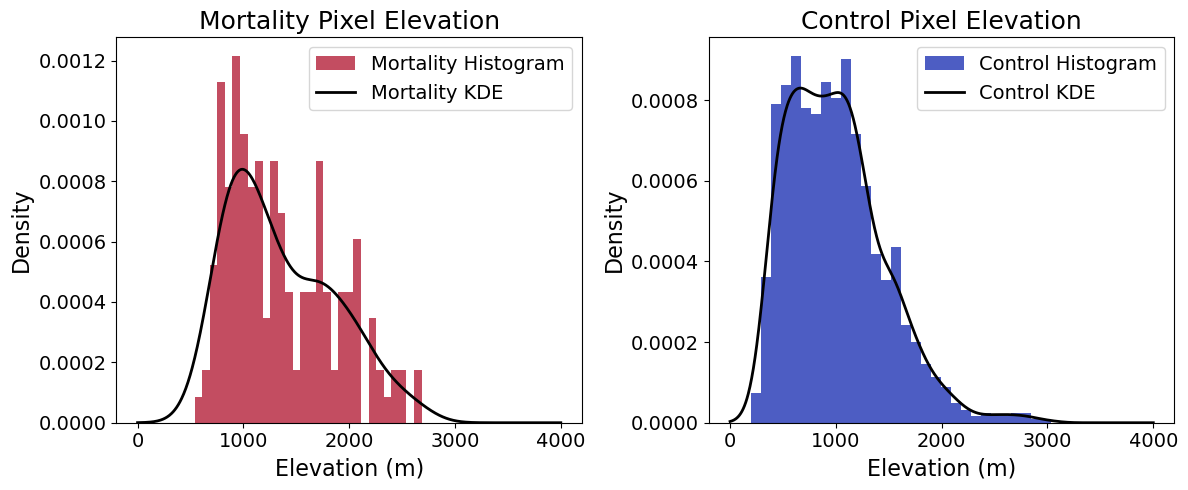

In [7]:

# Determine the statistical difference between the distributions of the control and mortality pixels using the Kolmogorov-Smirnov test
# We use the statistic from this test to scale each variable's sampled control pixel "distances" from the mortality pixels later
stat_elev, _ = ks_2samp(elev_control_non_nan, elev_mortality_non_nan)
print(f"Kolmogorov-Smirnov statistic comparing mortality and control distributions of elevation: {stat_elev:.4f}")


# Set global matplotlib font sizes for axes and legends
plt.rcParams.update({
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
# Plot histograms of elev_mortality_non_nan and elev_control_non_nan with KDE overlays
plt.figure(figsize=(12, 5))

# Elevation histogram + KDE for Mortality
plt.subplot(1, 2, 1)
plt.hist(elev_mortality_non_nan, bins=30, color=mortality_color, alpha=0.7, density=True, label='Mortality Histogram')
plt.plot(elevation_range, elev_mortality_density, color='black', linewidth=2, label='Mortality KDE')
plt.xlabel('Elevation (m)')
plt.ylabel('Density')
plt.title('Mortality Pixel Elevation')
plt.legend()

# Elevation histogram + KDE for Control
plt.subplot(1, 2, 2)
plt.hist(elev_control_non_nan, bins=30, color=control_color, alpha=0.7, density=True, label='Control Histogram')
plt.plot(elevation_range, elev_control_density, color='black', linewidth=2, label='Control KDE')
plt.xlabel('Elevation (m)')
plt.ylabel('Density')
plt.title('Control Pixel Elevation')
plt.legend()

plt.tight_layout()
plt.show()

Let's do the same, but for tree canopy cover (TCC) data

Kolmogorov-Smirnov statistic comparing mortality and control distributions of tree canopy cover: 0.3405


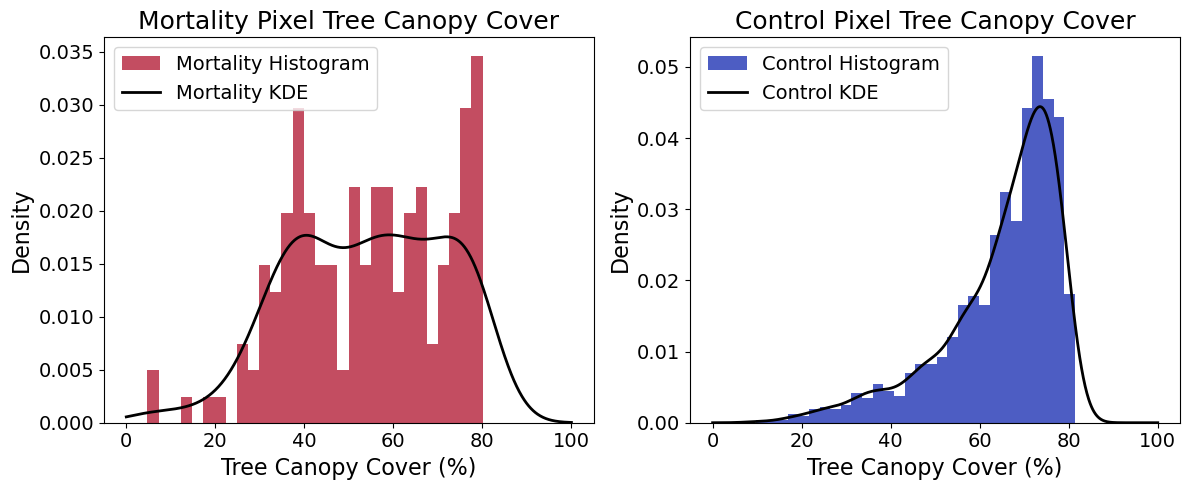

In [8]:
# Determine the statistical difference between the distributions of the control and mortality pixels using the Kolmogorov-Smirnov test
# We use the statistic from this test to scale each variable's sampled control pixel "distances" from the mortality pixels later
stat_TCC, _ = ks_2samp(TCC_control_non_nan, TCC_mortality_non_nan)
print(f"Kolmogorov-Smirnov statistic comparing mortality and control distributions of tree canopy cover: {stat_TCC:.4f}")


# Plot histograms of TCC_mortality_non_nan and TCC_control_non_nan with KDE overlays
plt.figure(figsize=(12, 5))

# Tree Canopy Cover histogram + KDE for Mortality
plt.subplot(1, 2, 1)
plt.hist(TCC_mortality_non_nan, bins=30, color=mortality_color, alpha=0.7, density=True, label='Mortality Histogram')
plt.plot(TCC_range, TCC_mortality_density, color='black', linewidth=2, label='Mortality KDE')
plt.xlabel('Tree Canopy Cover (%)')
plt.ylabel('Density')
plt.title('Mortality Pixel Tree Canopy Cover')
plt.legend()

# Tree Canopy Cover histogram + KDE for Control
plt.subplot(1, 2, 2)
plt.hist(TCC_control_non_nan, bins=30, color=control_color, alpha=0.7, density=True, label='Control Histogram')
plt.plot(TCC_range, TCC_control_density, color='black', linewidth=2, label='Control KDE')
plt.xlabel('Tree Canopy Cover (%)')
plt.ylabel('Density')
plt.title('Control Pixel Tree Canopy Cover')
plt.legend()

plt.tight_layout()
plt.show()


We can also do this for latitude:

Kolmogorov-Smirnov statistic comparing mortality and control distributions of latitude: 0.5596


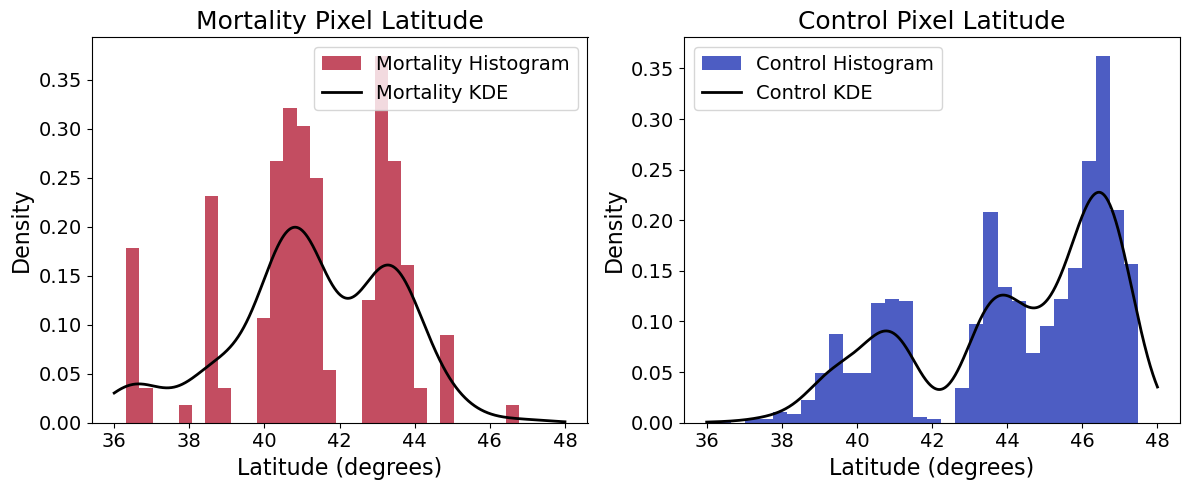

In [9]:
# Determine the statistical difference between the distributions of the control and mortality pixels using the Kolmogorov-Smirnov test
# We use the statistic from this test to scale each variable's sampled control pixel "distances" from the mortality pixels later
stat_latitude, _ = ks_2samp(latitude_control_non_nan, latitude_mortality_non_nan)
print(f"Kolmogorov-Smirnov statistic comparing mortality and control distributions of latitude: {stat_latitude:.4f}")

# Plot histograms of latitude_mortality_non_nan and latitude_control_non_nan with KDE overlays
plt.figure(figsize=(12, 5))

# Tree Canopy Cover histogram + KDE for Mortality
plt.subplot(1, 2, 1)
plt.hist(latitude_mortality_non_nan, bins=30, color=mortality_color, alpha=0.7, density=True, label='Mortality Histogram')
plt.plot(latitude_range, latitude_mortality_density, color='black', linewidth=2, label='Mortality KDE')
plt.xlabel('Latitude (degrees)')
plt.ylabel('Density')
plt.title('Mortality Pixel Latitude')
plt.legend()

# Tree Canopy Cover histogram + KDE for Control
plt.subplot(1, 2, 2)
plt.hist(latitude_control_non_nan, bins=30, color=control_color, alpha=0.7, density=True, label='Control Histogram')
plt.plot(latitude_range, latitude_control_density, color='black', linewidth=2, label='Control KDE')
plt.xlabel('Latitude (degrees)')
plt.ylabel('Density')
plt.title('Control Pixel Latitude')
plt.legend()

plt.tight_layout()
plt.show()


### Which variable has the most similar distribution between mortality and control?

We answer this question by comparing the Kolmogorov-Smirnov statistics of the different variables.

The lowest K-S value is from the elevation comparisons. The Highest K-S value is from the latitude comparisons.

From these, we will create weights for each variable that inform us how strongly to nudge the sampled control pixels towards the mortality pixels' values of elevation, tree canopy cover and latitude.

In [10]:
# Use KS statistic as weight (larger KS statistic = more different distributions = higher weight)

min_stat = min(stat_elev, stat_TCC, stat_latitude)
print(f"Minimum KS statistic: {min_stat:.4f} (out of elevation: {stat_elev:.4f}, TCC: {stat_TCC:.4f}, latitude: {stat_latitude:.4f})")

diff_scale_elev = stat_elev / min(stat_elev, stat_TCC, stat_latitude)
diff_scale_TCC = stat_TCC / min(stat_elev, stat_TCC, stat_latitude)
diff_scale_latitude = stat_latitude / min(stat_elev, stat_TCC, stat_latitude)

print(f"KS stat-based weight for elevation: {diff_scale_elev:.4f} = {stat_elev:.4f} / {min_stat:.4f}")
print(f"KS stat-based weight for TCC: {diff_scale_TCC:.4f} = {stat_TCC:.4f} / {min_stat:.4f}")
print(f"KS stat-based weight for latitude: {diff_scale_latitude:.4f} = {stat_latitude:.4f} / {min_stat:.4f}")

Minimum KS statistic: 0.2901 (out of elevation: 0.2901, TCC: 0.3405, latitude: 0.5596)
KS stat-based weight for elevation: 1.0000 = 0.2901 / 0.2901
KS stat-based weight for TCC: 1.1737 = 0.3405 / 0.2901
KS stat-based weight for latitude: 1.9288 = 0.5596 / 0.2901


Now, when we perform random draws of mortality pixels, we will record the elevation, tree canopy cover and latitude of these sampled pixels. From these values, will then sample new values of elevation, tree canopy cover and latitude that fall within a reasonable distance from each of those values. We will then compute the distances of all gridded values, weighting by these variable-specific factors.

Specifically, since latitude is already the least similar variable between the mortality and control pixel groups, this weighting factor tells us to multiply those distances by this factor for greater nudging of control pixel selection towards the mortality pixel's latitude

### Bootstrap implementation

Now let's demonstrate how the bootstrap works. First, we will iterate through the resampling procedure and display a map of the sampled mortality and control pixels, along with the KDEs of the elevation and TCC data for each iteration. 

Note that the resampling approach is specifically designed to minimize the distance in elevation and TCC between the mortality dataset and the control-resampled dataset. So for each iteration, a new set of control pixels are selected which should roughly match the elevation and TCC distributions of the mortality pixels.

When executing this code block, the map and KDEs will update with each iteration - when viewing statically, it just shows the final iteration of the bootstrap.

#### A single sample iteration - randomly selecting mortality pixels with replacement

First let's demonstrate how the mortality pixels are randomly sampled. The geopandas geodataframe has a built-in sample function which we use

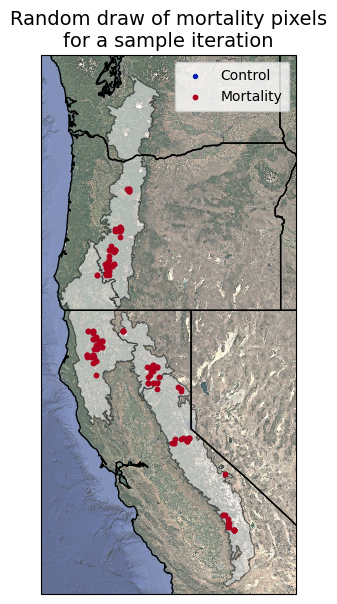

In [14]:
# Randomly sample rows of the mortality_polygon_gdf object (replace must be set to True)
mortality_polygon_gdf_sampled = mortality_polygon_gdf.sample(num_mortality_pixels, replace=True)
mortality_sampled_x = mortality_polygon_gdf_sampled.centroid.x
mortality_sampled_y = mortality_polygon_gdf_sampled.centroid.y

map_functions.plot_mortality_control_pixel_map([], [], mortality_sampled_x, mortality_sampled_y, plotTitle='Random draw of mortality pixels\nfor a sample iteration')


### Sampling the paired control pixel

for each of the sampled mortality pixels, we select a single control pixel that is similar to that mortality pixel's elevation, tree canopy cover and latitude. Here's an example of how we do that for a single pixel

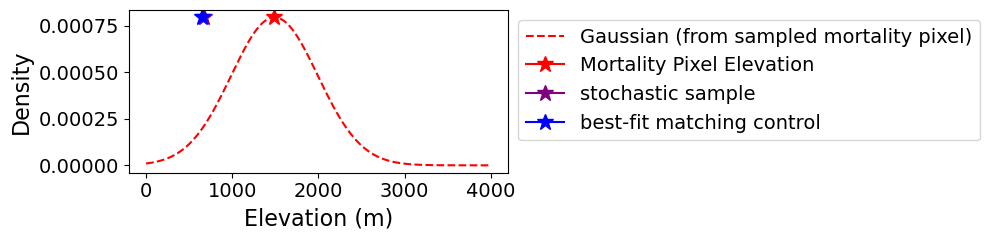

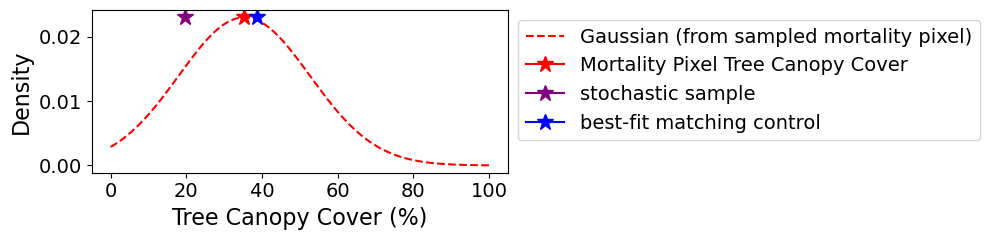

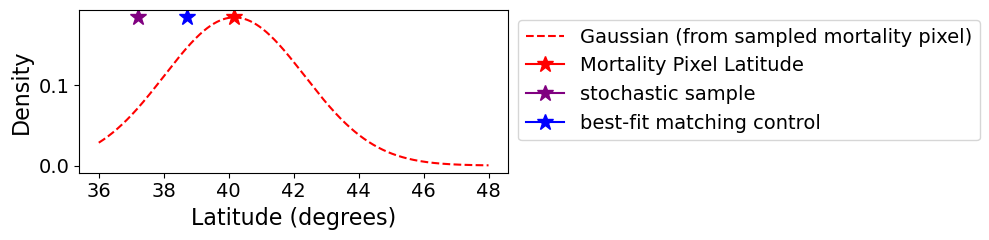

In [13]:
# Get the first pixel element of the resampled mortality polygon object
mortality_pixel = mortality_polygon_gdf_sampled.iloc[0]
centroid = mortality_pixel.geometry.centroid

# get the elevation, Tree Canopy Cover and latitude values for this pixel
mortality_elev = elev_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['elevation'].item()
mortality_TCC = TCC_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['tree_canopy_cover'].item()
mortality_latitude = centroid.y

# set gaussian distributions using the pixel's elevation, tree canopy cover and latitude
elev_normal = norm.pdf(elevation_range, loc=mortality_elev, scale=elev_mortality_std)
TCC_normal = norm.pdf(TCC_range, loc=mortality_TCC, scale=TCC_mortality_std)
latitude_normal = norm.pdf(latitude_range, loc=mortality_latitude, scale=latitude_mortality_std)

### FOR SELECTING MATCHED CONTROL PIXEL:
# Randomly sample values from these normal distributions
rand_elev_value = np.random.normal(loc=mortality_elev, scale=elev_mortality_std)
rand_TCC_value = np.random.normal(loc=mortality_TCC, scale=TCC_mortality_std)
rand_latitude_value = np.random.normal(loc=mortality_latitude, scale=latitude_mortality_std)

# Calculate the normalized differences of each var
elev_diffs = np.abs(elev_control_flat - rand_elev_value)/elev_control_std # divide by std to normalize
TCC_diffs = np.abs(TCC_control_flat - rand_TCC_value)/TCC_control_std # divide by std to normalize
lat_diffs = np.abs(latitude_control_flat - rand_latitude_value)/latitude_control_std # divide by std to normalize

# Combine constraints: find indices where combined differences are minimal
overall_diffs = (diff_scale_elev * elev_diffs) + (diff_scale_TCC * TCC_diffs) + (diff_scale_latitude * lat_diffs)
matching_idx = np.nanargmin(overall_diffs) # identify the index of the minimum difference
sampled_coord = np.unravel_index(matching_idx, elev_xr_control_clip.elevation.shape)
x_coord = elev_xr_control_clip.x.values[sampled_coord[1]]
y_coord = elev_xr_control_clip.y.values[sampled_coord[0]]

control_elev = elev_xr_control_clip.elevation.sel(x=x_coord, y=y_coord, method="nearest").item()
control_TCC = TCC_xr_control_clip.tree_canopy_cover.sel(x=x_coord, y=y_coord, method="nearest").item()
control_latitude = latitude_xr_control_clip.latitude.sel(x=x_coord, y=y_coord, method="nearest").item()

##########################################################
### plot the normal distribution represented by the mortality pixels' elevation, tree canopy cover and latitude
##########################################################

### Plot elevation values
plt.figure(figsize=(10, 2.5))
# Plot normal distribution with elev_value as mean and elev_mortality_std as std
plt.plot(elevation_range, elev_normal, color='red', linestyle='--', label='Gaussian (from sampled mortality pixel)')
# Plot a star where relevant values fall on the distribution
plt.plot(mortality_elev, norm.pdf(mortality_elev, loc=mortality_elev, scale=elev_mortality_std), marker='*', color='red', markersize=12, label='Mortality Pixel Elevation')
plt.plot(rand_elev_value, norm.pdf(rand_elev_value, loc=rand_elev_value, scale=elev_mortality_std), marker='*', color='purple', markersize=12, label='stochastic sample')
plt.plot(control_elev, norm.pdf(control_elev, loc=control_elev, scale=elev_mortality_std), marker='*', color='blue', markersize=12, label='best-fit matching control')
plt.ylabel('Density')
plt.xlabel('Elevation (m)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Plot tree canopy cover values
plt.figure(figsize=(10, 2.5))
# Plot normal distribution with TCC_value as mean and TCC_mortality_std as std
plt.plot(TCC_range, TCC_normal, color='red', linestyle='--', label='Gaussian (from sampled mortality pixel)')
# Plot a star where relevant values fall on the distribution
plt.plot(mortality_TCC, norm.pdf(mortality_TCC, loc=mortality_TCC, scale=TCC_mortality_std), marker='*', color='red', markersize=12, label='Mortality Pixel Tree Canopy Cover')
plt.plot(rand_TCC_value, norm.pdf(rand_TCC_value, loc=rand_TCC_value, scale=TCC_mortality_std), marker='*', color='purple', markersize=12, label='stochastic sample')
plt.plot(control_TCC, norm.pdf(control_TCC, loc=control_TCC, scale=TCC_mortality_std), marker='*', color='blue', markersize=12, label='best-fit matching control')
plt.ylabel('Density')
plt.xlabel('Tree Canopy Cover (%)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Plot latitude values
plt.figure(figsize=(10, 2.5))
# Plot normal distribution with latitude_value as mean and latitude_mortality_std as std
plt.plot(latitude_range, latitude_normal, color='red', linestyle='--', label='Gaussian (from sampled mortality pixel)')
# Plot a star where relevant values fall on the distribution
plt.plot(mortality_latitude, norm.pdf(mortality_latitude, loc=mortality_latitude, scale=latitude_mortality_std), marker='*', color='red', markersize=12, label='Mortality Pixel Latitude')
plt.plot(rand_latitude_value, norm.pdf(rand_latitude_value, loc=rand_latitude_value, scale=latitude_mortality_std), marker='*', color='purple', markersize=12, label='stochastic sample')
plt.plot(control_latitude, norm.pdf(control_latitude, loc=control_latitude, scale=latitude_mortality_std), marker='*', color='blue', markersize=12, label='best-fit matching control')
plt.ylabel('Density')
plt.xlabel('Latitude (degrees)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### After sampling all the paired controls, control groups' distributions of elevation, tree canopy cover and latitude should be more similar to those of the mortality pixel group

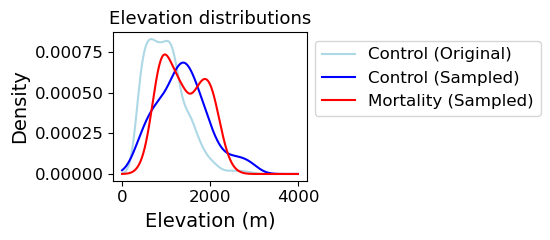

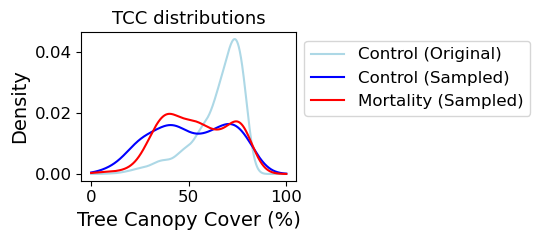

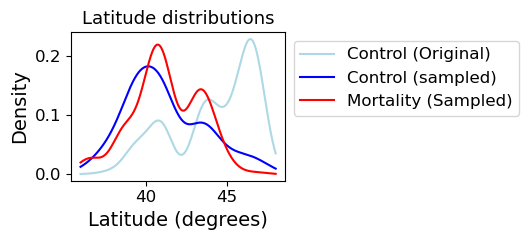

In [ ]:
mortality_sampled_elev_arr = []
mortality_sampled_TCC_arr = []
mortality_sampled_latitude_arr = []

control_sampled_elev_arr = []
control_sampled_TCC_arr = []
control_sampled_latitude_arr = []

matching_indices = []
# Randomly sample rows of the mortality_polygon_gdf object
mortality_polygon_gdf_sampled = mortality_polygon_gdf.sample(num_mortality_pixels, replace=True)


# Loop through each mortality pixel to pick a suitable pair
for ii, mortality_pixel in enumerate(mortality_polygon_gdf_sampled.itertuples()):

    centroid = mortality_pixel.geometry.centroid

    mortality_pixel_vals = SIF_annual_xr_scale.sel(x=centroid.x, y=centroid.y, method="nearest").values

    elev_value = elev_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['elevation'].item()
    TCC_value = TCC_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['tree_canopy_cover'].item()
    latitude_value = centroid.y

    # Keep track of the sampled elevation, TCC, latitude values
    mortality_sampled_elev_arr.append(elev_value)
    mortality_sampled_TCC_arr.append(TCC_value)
    mortality_sampled_latitude_arr.append(latitude_value)
    # print(f"Mortality pixel centroid: ({centroid.x}, {centroid.y}) | Elevation: {elev_value} | TCC: {TCC_value} | Latitude: {latitude_value}")

    control_pixel_vals = np.full_like(mortality_pixel_vals, np.nan)
    while(np.any(np.isnan(control_pixel_vals))):
        # sample new values from sample distributions from the pixels
        rand_elev_value = np.random.normal(loc=elev_value, scale=elev_mortality_std)
        rand_TCC_value = np.random.normal(loc=TCC_value, scale=TCC_mortality_std)
        rand_latitude_value = np.random.normal(loc=latitude_value, scale=latitude_mortality_std)

        # Calculate the normalized differences of each var
        elev_diffs = np.abs(elev_control_flat - rand_elev_value)/elev_control_std # divide by std to normalize
        TCC_diffs = np.abs(TCC_control_flat - rand_TCC_value)/TCC_control_std # divide by std to normalize
        lat_diffs = np.abs(latitude_control_flat - rand_latitude_value)/latitude_control_std # divide by std to normalize

        # Combine constraints: find indices where combined differences are minimal
        overall_diffs = (diff_scale_elev * elev_diffs) + (diff_scale_TCC * TCC_diffs) + (diff_scale_latitude * lat_diffs)
        matching_idx = np.nanargmin(overall_diffs) # identify the index of the minimum difference

        matching_indices.append(matching_idx)
        sampled_coord = np.unravel_index(matching_idx, elev_xr_control_clip.elevation.shape)
        
        # Extract x and y coordinates as indices from the original datasets' grid
        x_coord = elev_xr_control_clip.x.values[sampled_coord[1]]
        y_coord = elev_xr_control_clip.y.values[sampled_coord[0]]
        control_pixel_vals = SIF_annual_xr_scale.sel(x=x_coord, y=y_coord, method="nearest").values

        # Keep track of the sampled elevation, TCC, latitude values
        control_sampled_elev_arr.append(elev_xr_control_clip.elevation.sel(x=x_coord, y=y_coord, method="nearest").item())
        control_sampled_TCC_arr.append(TCC_xr_control_clip.tree_canopy_cover.sel(x=x_coord, y=y_coord, method="nearest").item())
        control_sampled_latitude_arr.append(y_coord)


# Set global matplotlib font sizes for axes and legends
plt.rcParams.update({
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})


elev_mortality_sampled_kde = gaussian_kde(mortality_sampled_elev_arr, bw_method='scott')
elev_control_sampled_kde = gaussian_kde(control_sampled_elev_arr, bw_method='scott')



plt.figure(figsize=(5.5, 2.5))
plt.plot(elevation_range, elev_control_kde.evaluate(elevation_range), color='lightblue', label='Control (Original)')
plt.plot(elevation_range, elev_control_sampled_kde.evaluate(elevation_range), color='blue', label='Control (Sampled)')
plt.plot(elevation_range, elev_mortality_sampled_kde.evaluate(elevation_range), color='red', label='Mortality (Sampled)')
plt.xlabel('Elevation (m)')
plt.ylabel('Density')
plt.title(f'Elevation distributions')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

TCC_mortality_sampled_kde = gaussian_kde(mortality_sampled_TCC_arr, bw_method='scott')
TCC_control_sampled_kde = gaussian_kde(control_sampled_TCC_arr, bw_method='scott')

plt.figure(figsize=(5.5, 2.5))
plt.plot(TCC_range, TCC_control_kde.evaluate(TCC_range), color='lightblue', label='Control (Original)')
plt.plot(TCC_range, TCC_control_sampled_kde.evaluate(TCC_range), color='blue', label='Control (Sampled)')
plt.plot(TCC_range, TCC_mortality_sampled_kde.evaluate(TCC_range), color='red', label='Mortality (Sampled)')
plt.xlabel('Tree Canopy Cover (%)')
plt.ylabel('Density')
plt.title(f'TCC distributions')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


latitude_mortality_sampled_kde = gaussian_kde(mortality_sampled_latitude_arr, bw_method='scott')
latitude_control_sampled_kde = gaussian_kde(control_sampled_latitude_arr, bw_method='scott')

plt.figure(figsize=(5.5, 2.5))
plt.plot(latitude_range, latitude_control_kde.evaluate(latitude_range), color='lightblue', label='Control (Original)')
plt.plot(latitude_range, latitude_control_sampled_kde.evaluate(latitude_range), color='blue', label='Control (sampled)')
plt.plot(latitude_range, latitude_mortality_sampled_kde.evaluate(latitude_range), color='red', label='Mortality (Sampled)')
plt.xlabel('Latitude (degrees)')
plt.ylabel('Density')
plt.title(f'Latitude distributions')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Let's loop through 30 sample bootstrap iterations of the bootstrap and show how the matched distributions vary 

In [11]:
years = SIF_annual_xr['year'].values
KDE_dir = os.path.join(plot_dir, 'KDE_plots')
elev_KDE_images = []
TCC_KDE_images = []
latitude_KDE_images = []

for ensemble_iter in range(30):
    clear_output(wait=True)
    print(f'Bootstrap iteration: {ensemble_iter:02d}')

    mortality_sampled_elev_arr = []
    mortality_sampled_TCC_arr = []
    mortality_sampled_latitude_arr = []

    control_sampled_elev_arr = []
    control_sampled_TCC_arr = []
    control_sampled_latitude_arr = []

    matching_indices = []

    #########################################
    # Establish Mortality datastructure
    #########################################
    bootstrap_SIF_ds = xr.Dataset(
        {
            "mortality": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
            "control": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
        },
        coords={
            "year": years,
            "pair_id": np.arange(num_mortality_pixels),
        }
    )
    bootstrap_coords_ds = xr.Dataset(
        {
            "mortality_lat": (["pair_id"], np.full((num_mortality_pixels), np.nan)),
            "mortality_lon": (["pair_id"], np.full((num_mortality_pixels), np.nan)),

            "control_lat": (["pair_id"], np.full((num_mortality_pixels), np.nan)),
            "control_lon": (["pair_id"], np.full((num_mortality_pixels), np.nan)),
        },
        coords={
            "pair_id": np.arange(num_mortality_pixels),
        }
    )

    # Randomly sample rows of the mortality_polygon_gdf object
    mortality_polygon_gdf_sampled = mortality_polygon_gdf.sample(num_mortality_pixels, replace=True)

    # Loop through each mortality pixel to pick a suitable pair
    for ii, mortality_pixel in enumerate(mortality_polygon_gdf_sampled.itertuples()):

        centroid = mortality_pixel.geometry.centroid

        mortality_pixel_vals = SIF_annual_xr[dat_var].sel(x=centroid.x, y=centroid.y, method="nearest").values

        elev_value = elev_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['elevation'].item()
        TCC_value = TCC_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['tree_canopy_cover'].item()
        latitude_value = centroid.y

        # Keep track of the sampled elevation, TCC, latitude values
        mortality_sampled_elev_arr.append(elev_value)
        mortality_sampled_TCC_arr.append(TCC_value)
        mortality_sampled_latitude_arr.append(latitude_value)
        # print(f"Mortality pixel centroid: ({centroid.x}, {centroid.y}) | Elevation: {elev_value} | TCC: {TCC_value} | Latitude: {latitude_value}")

        control_pixel_vals = np.full_like(mortality_pixel_vals, np.nan)
        while(np.any(np.isnan(control_pixel_vals))):
            # sample new values from sample distributions from the pixels
            rand_elev_value = np.random.normal(loc=elev_value, scale=elev_mortality_std)
            rand_TCC_value = np.random.normal(loc=TCC_value, scale=TCC_mortality_std)
            rand_latitude_value = np.random.normal(loc=latitude_value, scale=latitude_mortality_std)

            # Calculate the normalized differences of each var
            elev_diffs = np.abs(elev_control_flat - rand_elev_value)/elev_control_std # divide by std to normalize
            TCC_diffs = np.abs(TCC_control_flat - rand_TCC_value)/TCC_control_std # divide by std to normalize
            lat_diffs = np.abs(latitude_control_flat - rand_latitude_value)/latitude_control_std # divide by std to normalize

            # Combine constraints: find indices where combined differences are minimal
            overall_diffs = (diff_scale_elev * elev_diffs) + (diff_scale_TCC * TCC_diffs) + (diff_scale_latitude * lat_diffs)
            matching_idx = np.nanargmin(overall_diffs) # identify the index of the minimum difference

            matching_indices.append(matching_idx)
            sampled_coord = np.unravel_index(matching_idx, elev_xr_control_clip.elevation.shape)
            
            # Extract x and y coordinates as indices from the original datasets' grid
            x_coord = elev_xr_control_clip.x.values[sampled_coord[1]]
            y_coord = elev_xr_control_clip.y.values[sampled_coord[0]]
            control_pixel_vals = SIF_annual_xr[dat_var].sel(x=x_coord, y=y_coord, method="nearest").values

            # Keep track of the sampled elevation, TCC, latitude values
            control_sampled_elev_arr.append(elev_xr_control_clip.elevation.sel(x=x_coord, y=y_coord, method="nearest").item())
            control_sampled_TCC_arr.append(TCC_xr_control_clip.tree_canopy_cover.sel(x=x_coord, y=y_coord, method="nearest").item())
            control_sampled_latitude_arr.append(y_coord)

    
    elev_mortality_sampled_kde = gaussian_kde(mortality_sampled_elev_arr, bw_method='scott')
    elev_control_sampled_kde = gaussian_kde(control_sampled_elev_arr, bw_method='scott')


    plt.figure(figsize=(6, 2.5))
    plt.plot(elevation_range, elev_control_kde.evaluate(elevation_range), color='lightblue', label='Control (Original)')
    plt.plot(elevation_range, elev_control_sampled_kde.evaluate(elevation_range), color='blue', label='Control (Sampled)')
    plt.plot(elevation_range, elev_mortality_sampled_kde.evaluate(elevation_range), color='red', label='Mortality (Sampled)')
    plt.xlabel('Elevation (m)')
    plt.ylabel('Density')
    plt.title(f'Elevation distributions, ii={ensemble_iter:02d}')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    KDE_file = os.path.join(KDE_dir, f'elevation_KDE_iter{ensemble_iter:02d}.png')
    plt.savefig(KDE_file)
    plt.close('all')
    elev_KDE_images.append(imageio.imread(KDE_file))

    TCC_mortality_sampled_kde = gaussian_kde(mortality_sampled_TCC_arr, bw_method='scott')
    TCC_control_sampled_kde = gaussian_kde(control_sampled_TCC_arr, bw_method='scott')

    plt.figure(figsize=(6, 2.5))
    plt.plot(TCC_range, TCC_control_kde.evaluate(TCC_range), color='lightblue', label='Control (Original)')
    plt.plot(TCC_range, TCC_control_sampled_kde.evaluate(TCC_range), color='blue', label='Control (Sampled)')
    plt.plot(TCC_range, TCC_mortality_sampled_kde.evaluate(TCC_range), color='red', label='Mortality (Sampled)')
    plt.xlabel('Tree Canopy Cover (%)')
    plt.ylabel('Density')
    plt.title(f'TCC distributions, ii={ensemble_iter:02d}')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    KDE_file = os.path.join(KDE_dir, f'TCC_KDE_iter{ensemble_iter:02d}.png')
    plt.savefig(KDE_file)
    plt.close('all')
    TCC_KDE_images.append(imageio.imread(KDE_file))

    latitude_mortality_sampled_kde = gaussian_kde(mortality_sampled_latitude_arr, bw_method='scott')
    latitude_control_sampled_kde = gaussian_kde(control_sampled_latitude_arr, bw_method='scott')

    plt.figure(figsize=(6, 2.5))
    plt.plot(latitude_range, latitude_control_kde.evaluate(latitude_range), color='lightblue', label='Control (Original)')
    plt.plot(latitude_range, latitude_control_sampled_kde.evaluate(latitude_range), color='blue', label='Control (sampled)')
    plt.plot(latitude_range, latitude_mortality_sampled_kde.evaluate(latitude_range), color='red', label='Mortality (Sampled)')
    plt.xlabel('Latitude (degrees)')
    plt.ylabel('Density')
    plt.title(f'Latitude distributions, ii={ensemble_iter:02d}')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    KDE_file = os.path.join(KDE_dir, f'latitude_KDE_iter{ensemble_iter:02d}.png')
    plt.savefig(KDE_file)
    plt.close('all')
    latitude_KDE_images.append(imageio.imread(KDE_file))
    

Bootstrap iteration: 29


##### Display the animation of the distributions

compiling KDE plots into animated GIF
GIF saved to out_plots/KDEs_elev.gif


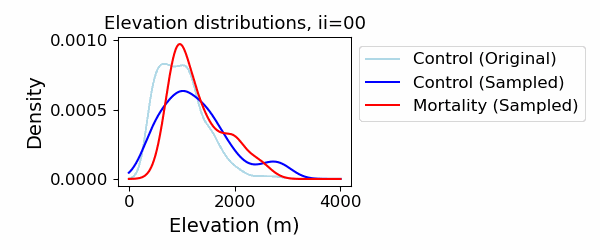

In [16]:
print('compiling KDE plots into animated GIF')
# Save the images as an animated GIF
gif_filepath = os.path.join(plot_dir, f'KDEs_elev.gif')
GIF_frame_time_sec = 0.4 # seconds per frame
imageio.mimwrite(gif_filepath, elev_KDE_images, fps = 1/GIF_frame_time_sec, loop=0)  # fps argument is frames per second
print(f'GIF saved to {gif_filepath}')
display(IPImage(filename=gif_filepath))

GIF saved to out_plots/KDEs_TCC.gif


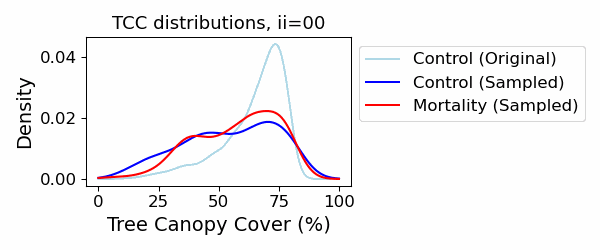

In [17]:
# Save the images as an animated GIF
gif_filepath = os.path.join(plot_dir, f'KDEs_TCC.gif')
GIF_frame_time_sec = 0.4 # seconds per frame
imageio.mimwrite(gif_filepath, TCC_KDE_images, fps = 1/GIF_frame_time_sec, loop=0)  # fps argument is frames per second
print(f'GIF saved to {gif_filepath}')
display(IPImage(filename=gif_filepath))

GIF saved to out_plots/KDEs_latitude.gif


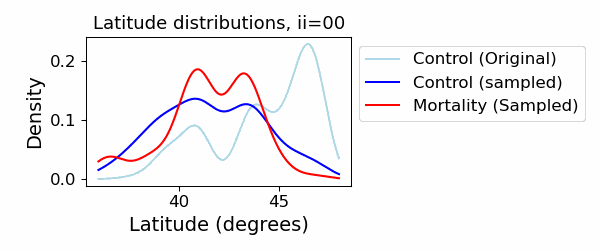

In [18]:
# Save the images as an animated GIF
gif_filepath = os.path.join(plot_dir, f'KDEs_latitude.gif')
GIF_frame_time_sec = 0.4 # seconds per frame
imageio.mimwrite(gif_filepath, latitude_KDE_images, fps = 1/GIF_frame_time_sec, loop=0)  # fps argument is frames per second
print(f'GIF saved to {gif_filepath}')
display(IPImage(filename=gif_filepath))

### Spatial visualization of the bootstrap resampled-pixel pairs

We will do the same thing - iterate through 30 sample bootstrap iterations, but make maps of the sampled mortality-control pixel pairs and loop through an animation to visualize how these change 

In [ ]:
years = SIF_annual_xr['year'].values
map_dir = os.path.join(plot_dir, 'pixel_maps')
images = []

for ensemble_iter in range(30):
    clear_output(wait=True)
    print(f'Bootstrap iteration: {ensemble_iter:02d}')

    #########################################
    # Establish Mortality datastructure
    #########################################
    bootstrap_SIF_ds = xr.Dataset(
        {
            "mortality": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
            "control": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
        },
        coords={
            "year": years,
            "pair_id": np.arange(num_mortality_pixels),
        }
    )
    bootstrap_coords_ds = xr.Dataset(
        {
            "mortality_lat": (["pair_id"], np.full((num_mortality_pixels), np.nan)),
            "mortality_lon": (["pair_id"], np.full((num_mortality_pixels), np.nan)),

            "control_lat": (["pair_id"], np.full((num_mortality_pixels), np.nan)),
            "control_lon": (["pair_id"], np.full((num_mortality_pixels), np.nan)),
        },
        coords={
            "pair_id": np.arange(num_mortality_pixels),
        }
    )

    # Randomly sample rows of the mortality_polygon_gdf object
    mortality_polygon_gdf_sampled = mortality_polygon_gdf.sample(num_mortality_pixels, replace=True)

    for ii, mortality_pixel in enumerate(mortality_polygon_gdf_sampled.itertuples()):

        centroid = mortality_pixel.geometry.centroid

        bootstrap_coords_ds['mortality_lat'].loc[ii] = centroid.y
        bootstrap_coords_ds['mortality_lon'].loc[ii] = centroid.x
        mortality_pixel_vals = SIF_annual_xr[dat_var].sel(x=centroid.x, y=centroid.y, method="nearest").values

        elev_value = elev_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['elevation'].item()
        TCC_value = TCC_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['tree_canopy_cover'].item()
        latitude_value = centroid.y
        # print(f"Mortality pixel centroid: ({centroid.x}, {centroid.y}) | Elevation: {elev_value} | TCC: {TCC_value} | Latitude: {latitude_value}")

        control_pixel_vals = np.full_like(mortality_pixel_vals, np.nan)
        while(np.any(np.isnan(control_pixel_vals))):
            # sample new values from sample distributions from the pixels
            rand_elev_value = np.random.normal(loc=elev_value, scale=elev_mortality_std)
            rand_TCC_value = np.random.normal(loc=TCC_value, scale=TCC_mortality_std)
            rand_latitude_value = np.random.normal(loc=latitude_value, scale=latitude_mortality_std)

            # Calculate the normalized differences of each var
            elev_diffs = np.abs(elev_control_flat - rand_elev_value)/elev_control_std # divide by std to normalize
            TCC_diffs = np.abs(TCC_control_flat - rand_TCC_value)/TCC_control_std # divide by std to normalize
            lat_diffs = np.abs(latitude_control_flat - rand_latitude_value)/latitude_control_std # divide by std to normalize

            # Combine constraints: find indices where combined differences are minimal
            overall_diffs = (diff_scale_elev * elev_diffs) + (diff_scale_TCC * TCC_diffs) + (diff_scale_latitude * lat_diffs)
            matching_idx = np.nanargmin(overall_diffs) # identify the index of the minimum difference
            sampled_coord = np.unravel_index(matching_idx, elev_xr_control_clip.elevation.shape)
            
            # Extract x and y coordinates as indices from the original datasets' grid
            x_coord = elev_xr_control_clip.x.values[sampled_coord[1]]
            y_coord = elev_xr_control_clip.y.values[sampled_coord[0]]
            bootstrap_coords_ds['control_lat'].loc[ii] = y_coord
            bootstrap_coords_ds['control_lon'].loc[ii] = x_coord
            control_pixel_vals = SIF_annual_xr[dat_var].sel(x=x_coord, y=y_coord, method="nearest").values

        bootstrap_SIF_ds['mortality'].loc[ii, :] = mortality_pixel_vals
        bootstrap_SIF_ds['control'].loc[ii, :] = control_pixel_vals

    summary_absolute_mean_df = functions.stat_summary(bootstrap_SIF_ds, reference_year = baseline_year)

    # elev_control_kde_sampled, elev_control_density_sampled, elev_control_non_nan_sampled = functions.compute_kde_density_from_gdf(control_polygon_gdf_sampled, elev_xr, 'elevation', elevation_range)
    # TCC_control_kde_sampled, TCC_control_density_sampled, TCC_control_non_nan_sampled = functions.compute_kde_density_from_gdf(control_polygon_gdf_sampled, TCC_xr, 'tree_canopy_cover', TCC_range)
    # latitude_control_kde_sampled, latitude_control_density_sampled, latitude_control_non_nan_sampled = functions.compute_kde_density_from_gdf(control_polygon_gdf_sampled, latitude_ds, 'latitude', latitude_range)   

    map_file = os.path.join(map_dir, f'pixel_map_ii{ensemble_iter:02d}.png')
    fig, ax = plt.subplots(subplot_kw={'projection': map_functions.crs}, figsize=(4, 5))
    map_functions.plot_mortality_control_pixel_map(bootstrap_coords_ds['control_lon'], bootstrap_coords_ds['control_lat'], bootstrap_coords_ds['mortality_lon'], bootstrap_coords_ds['mortality_lat'], plotTitle=f'Bootstrap Iteration: {ensemble_iter:02d}', fig=fig, ax=ax)
    plt.savefig(map_file, format = 'png', bbox_inches="tight")
    # plt.show()
    plt.close()
    
    images.append(imageio.imread(map_file))
    


Bootstrap iteration: 29


compiling pixel maps into animated GIF
GIF saved to out_plots/maps_mortality_control_pixels_ensemble.gif


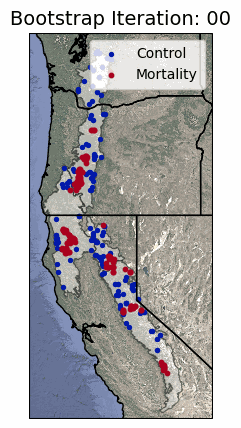

In [20]:
print('compiling pixel maps into animated GIF')
# Save the images as an animated GIF
gif_filepath = os.path.join(plot_dir, f'maps_mortality_control_pixels_ensemble.gif')
GIF_frame_time_sec = 0.4 # seconds per frame

try:
   imageio.mimwrite(gif_filepath, images, fps = 1/GIF_frame_time_sec, loop=0)  # fps argument is frames per second

# If images aren't the same size, resize them to a common size
except ValueError:
   resized_images = []
   desired_size = (480, 1000)  # Set the desired size to which all images should be resized
   for img_array in images:
      img = Image.fromarray(img_array)
      img_resized = img.resize(desired_size, Image.LANCZOS)
      resized_images.append(np.array(img_resized))
   imageio.mimwrite(gif_filepath, resized_images, fps = 1/GIF_frame_time_sec, loop=0)  # fps argument is frames per second

print(f'GIF saved to {gif_filepath}')
display(IPImage(filename=gif_filepath))

In [11]:
years = SIF_annual_xr['year'].values
summary_dir = os.path.join(plot_dir, 'summary_plots')
annual_images = []

for ensemble_iter in range(30):
    clear_output(wait=True)
    print(f'Bootstrap iteration: {ensemble_iter:02d}')

    #########################################
    # Establish Mortality datastructure
    #########################################
    bootstrap_SIF_ds = xr.Dataset(
        {
            "mortality": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
            "control": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
        },
        coords={
            "year": years,
            "pair_id": np.arange(num_mortality_pixels),
        }
    )

    # Randomly sample rows of the mortality_polygon_gdf object
    mortality_polygon_gdf_sampled = mortality_polygon_gdf.sample(num_mortality_pixels, replace=True)

    for ii, mortality_pixel in enumerate(mortality_polygon_gdf_sampled.itertuples()):

        centroid = mortality_pixel.geometry.centroid

        mortality_pixel_vals = SIF_annual_xr_scale.sel(x=centroid.x, y=centroid.y, method="nearest").values

        elev_value = elev_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['elevation'].item()
        TCC_value = TCC_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['tree_canopy_cover'].item()
        latitude_value = centroid.y
        # print(f"Mortality pixel centroid: ({centroid.x}, {centroid.y}) | Elevation: {elev_value} | TCC: {TCC_value} | Latitude: {latitude_value}")

        control_pixel_vals = np.full_like(mortality_pixel_vals, np.nan)
        while(np.any(np.isnan(control_pixel_vals))):
            # sample new values from sample distributions from the pixels
            rand_elev_value = np.random.normal(loc=elev_value, scale=elev_mortality_std)
            rand_TCC_value = np.random.normal(loc=TCC_value, scale=TCC_mortality_std)
            rand_latitude_value = np.random.normal(loc=latitude_value, scale=latitude_mortality_std)

            # Calculate the normalized differences of each var
            elev_diffs = np.abs(elev_control_flat - rand_elev_value)/elev_control_std # divide by std to normalize
            TCC_diffs = np.abs(TCC_control_flat - rand_TCC_value)/TCC_control_std # divide by std to normalize
            lat_diffs = np.abs(latitude_control_flat - rand_latitude_value)/latitude_control_std # divide by std to normalize

            # Combine constraints: find indices where combined differences are minimal
            overall_diffs = (diff_scale_elev * elev_diffs) + (diff_scale_TCC * TCC_diffs) + (diff_scale_latitude * lat_diffs)
            matching_idx = np.nanargmin(overall_diffs) # identify the index of the minimum difference
            sampled_coord = np.unravel_index(matching_idx, elev_xr_control_clip.elevation.shape)
            
            # Extract x and y coordinates as indices from the original datasets' grid
            x_coord = elev_xr_control_clip.x.values[sampled_coord[1]]
            y_coord = elev_xr_control_clip.y.values[sampled_coord[0]]
            control_pixel_vals = SIF_annual_xr_scale.sel(x=x_coord, y=y_coord, method="nearest").values

        bootstrap_SIF_ds['mortality'].loc[ii, :] = mortality_pixel_vals
        bootstrap_SIF_ds['control'].loc[ii, :] = control_pixel_vals

    summary_absolute_mean_df = functions.stat_summary(bootstrap_SIF_ds, reference_year = baseline_year)

    fig, ax = plt.subplots(figsize=(3.5, 2))
    functions.plot_summary(summary_df = summary_absolute_mean_df, 
            plot_title = f'Bootstrap iter={ensemble_iter:02d} - Annual Mean', 
            yax_label = r'SIF$_{dc}$ (% rel to 2019)',
            mortality_year = mortality_year, fig=fig, ax=ax, draw_box = True)
    annual_file = os.path.join(summary_dir, f'annual_iter{ensemble_iter:02d}.png')
    plt.savefig(annual_file)
    plt.close('all')
    annual_images.append(imageio.imread(annual_file))

Bootstrap iteration: 29


GIF saved to out_plots/summary_annual.gif


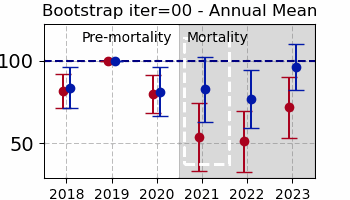

In [12]:
# Save the images as an animated GIF
gif_filepath = os.path.join(plot_dir, f'summary_annual.gif')
GIF_frame_time_sec = 0.4 # seconds per frame
imageio.mimwrite(gif_filepath, annual_images, fps = 1/GIF_frame_time_sec, loop=0)  # fps argument is frames per second
print(f'GIF saved to {gif_filepath}')
display(IPImage(filename=gif_filepath))

Now we re-iterate through the resampling procedure to perform the actual calculations of mortality-control comparisons. 

Importantly, we now add the TROPOMI SIF data to each of the pixels using the custom pixel_group class (see include/pixel_classes.py) and filter for only the months of interest (in this case - August, September, and October) and aggregate annually.

This code block plots a four-panel figure (details below)

Top left: For the given loop iteration, this is a comparison of the mean (+/- standard deviation) late-summer TROPOMI SIF for mortality (in red) vs control (in blue) from 2018-2023. The gray shaded region represents the estimated year that mortality onset occurred.

Top right: For the given loop iteration, this is a comparison of the mean (+/- standard deviation) 1-yr change in late-summer TROPOMI SIF (1-yr ΔSIF), with the same color scheme as top-left. The year 2022 is denoted with a dashed white box because the bottom panels represent the cumulative statistics for 1-yr ΔSIF in 2022.

Bottom left: Shows the running-mean difference between mortality and control vs number of cumulative bootstrap iterations. The shaded regions represent the 95% confidence intervals (because they are quantiles, they have less variation with increasing iterations compared to the mean). Note that this quantity is the DIFFERENCE in 1-yr ΔSIF BETWEEN mortality and control, so positive values mean that the 1-yr ΔSIF was higher for mortality pixels than control pixels, and negative values mean that the 1-yr ΔSIF was lowwer for mortality pixels than for control pixels.

Bottom right: shows the running mean p-value from the Mann-Whitney test vs number of cumulative bootstrap iterations, comparing the mortality and control 1-yr ΔSIF values. p values of 0.05 and 0.01 are shown for reference. 

In [13]:
years = SIF_annual_xr['year'].values
summary_ann_mean_arr = []
summary_1yr_delta_arr = []
summary_2yr_delta_arr = []

for ensemble_iter in range(num_repeats):
    clear_output(wait=True)
    print(f'Bootstrap iteration: {ensemble_iter:02d}')

    #########################################
    # Establish Mortality datastructure
    #########################################
    bootstrap_SIF_ds = xr.Dataset(
        {
            "mortality": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
            "control": (["pair_id", "year"], np.full((num_mortality_pixels, len(years)), np.nan)),
        },
        coords={
            "year": years,
            "pair_id": np.arange(num_mortality_pixels),
        }
    )

    # Randomly sample rows of the mortality_polygon_gdf object
    mortality_polygon_gdf_sampled = mortality_polygon_gdf.sample(num_mortality_pixels, replace=True)

    for ii, mortality_pixel in enumerate(mortality_polygon_gdf_sampled.itertuples()):

        centroid = mortality_pixel.geometry.centroid

        mortality_pixel_vals = SIF_annual_xr_scale.sel(x=centroid.x, y=centroid.y, method="nearest").values

        elev_value = elev_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['elevation'].item()
        TCC_value = TCC_xr.sel(x=centroid.x, y=centroid.y, method="nearest")['tree_canopy_cover'].item()
        latitude_value = centroid.y
        # print(f"Mortality pixel centroid: ({centroid.x}, {centroid.y}) | Elevation: {elev_value} | TCC: {TCC_value} | Latitude: {latitude_value}")

        control_pixel_vals = np.full_like(mortality_pixel_vals, np.nan)
        while(np.any(np.isnan(control_pixel_vals))):
            # sample new values from sample distributions from the pixels
            rand_elev_value = np.random.normal(loc=elev_value, scale=elev_mortality_std)
            rand_TCC_value = np.random.normal(loc=TCC_value, scale=TCC_mortality_std)
            rand_latitude_value = np.random.normal(loc=latitude_value, scale=latitude_mortality_std)

            # Calculate the normalized differences of each var
            elev_diffs = np.abs(elev_control_flat - rand_elev_value)/elev_control_std # divide by std to normalize
            TCC_diffs = np.abs(TCC_control_flat - rand_TCC_value)/TCC_control_std # divide by std to normalize
            lat_diffs = np.abs(latitude_control_flat - rand_latitude_value)/latitude_control_std # divide by std to normalize

            # Combine constraints: find indices where combined differences are minimal
            overall_diffs = (diff_scale_elev * elev_diffs) + (diff_scale_TCC * TCC_diffs) + (diff_scale_latitude * lat_diffs)
            matching_idx = np.nanargmin(overall_diffs) # identify the index of the minimum difference
            sampled_coord = np.unravel_index(matching_idx, elev_xr_control_clip.elevation.shape)
            
            # Extract x and y coordinates as indices from the original datasets' grid
            x_coord = elev_xr_control_clip.x.values[sampled_coord[1]]
            y_coord = elev_xr_control_clip.y.values[sampled_coord[0]]
            control_pixel_vals = SIF_annual_xr_scale.sel(x=x_coord, y=y_coord, method="nearest").values

        bootstrap_SIF_ds['mortality'].loc[ii, :] = mortality_pixel_vals
        bootstrap_SIF_ds['control'].loc[ii, :] = control_pixel_vals

    summary_absolute_mean_df = functions.stat_summary(bootstrap_SIF_ds, reference_year = baseline_year)
    summary_ann_mean_arr.append(summary_absolute_mean_df)

    

Bootstrap iteration: 99


### Final results

Now that the bootstrap has been fully iterated, we can plot the average results. This will take the summary statistics across all the iterations and plot the mean +/- standard deviation for each year. There are two plots, one for the mean late-summer TROPOMI SIF and one for the 1-yr ΔSIF.

Note that the `*` character above the annual mortality/control comparisons indicates statistical significance according to the bootstrap confidence interval, where:

`*` = 95% confidence interval does not include 0

`**` = 99% confidence interval does not include 0

`***` = 99.9% confidence interval does not include 0

Similarly, the `+` character indicates significance according to the Mann-Whitney test, where:

`+` = p < 0.05

`++` = p < 0.01

`+++` = p < 0.001

If there are no significant results according to these thresholds, there will be no characters shown.

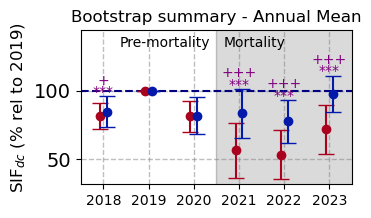

In [14]:

summary_ann_mean = functions.calculate_mean_across_dataframes(summary_ann_mean_arr)
summary_ann_mean = functions.add_significance_columns(summary_ann_mean)

fig, ax = plt.subplots(figsize=(3.5, 2))
functions.plot_summary(summary_df = summary_ann_mean, 
      plot_title = r'Bootstrap summary - Annual Mean', 
      yax_label = r'SIF$_{dc}$ (% rel to 2019)',
      mortality_year = mortality_year,
      fig=fig, ax=ax, plot_significance_chars=True)
plt.show()



### Computing the difference between mortality and control

To compute mortality-control differences, we take the median of the differences recorded in the bootstrapping stage

In [15]:
print('Annual SIF:')
mean_diff_annual = summary_ann_mean[summary_ann_mean['year'] == mortality_year]['mean_diff'].item()
print(f'Median difference (mortality - control) in year {mortality_year}: {mean_diff_annual:.3f} %')


Annual SIF:
Median difference (mortality - control) in year 2021: -27.311 %
